In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.95'
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')

%load_ext autoreload
%autoreload 2


/tmp/ipykernel_2423490/940688415.py:5: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


/projects/bdne/spandey3/envs/charm/lib/python3.10/site-packages/tqdm-4.66.5-py3.10.egg/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
deproj = 'cib_1p7_dBeta'
# deproj = 'cib_1p7'
probe = 'all'
smooth_mm_model = 'response'
smooth_ym_model = 'response'


# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.783, 'ns': 0.95, 'w0':-1.0}
cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.95, 'w0':-1.0}
sim_params_dict = {}
sim_params_dict['nfw_trunc'] = True
sim_params_dict['gamma_rhogas'] = 2.5
sim_params_dict['delta_rhogas'] = 7.0
# sim_params_dict['theta_co'] = 0.01
# sim_params_dict['theta_ej'] = 1.0

sim_params_dict['theta_co_0'] = 0.1
sim_params_dict['log10_Mstar0_theta_co'] = 15.0
sim_params_dict['nu_theta_co_M'] = -0.25
sim_params_dict['nu_theta_co_z'] = -0.5

sim_params_dict['theta_ej_0'] = 4.15
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
sim_params_dict['nu_theta_ej_M'] = 0.0
sim_params_dict['nu_theta_ej_z'] = 1.0

sim_params_dict['log10_Mc0'] = 13.0
sim_params_dict['log10_Mstar0'] = 15.0
sim_params_dict['mu_beta'] = 0.5
sim_params_dict['nu_z'] = 0.1
sim_params_dict['nu_M'] = 0.1

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.4


sim_params_dict['neg_bhse_plus_1'] = 0.833
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4
sim_params_dict['epsilon_rt'] = 4.0


sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2
sim_params_dict['alpha_nt'] = 0.18
sim_params_dict['beta_nt'] = 0.5
sim_params_dict['n_nt'] = 0.3
sim_params_dict['cosmo'] = cosmo_params_dict

sim_params_dict['alpha_1h2h_mm'] = 1.0
sim_params_dict['alpha_1h2h_ym'] = 1.0


halo_params_dict = {}
halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 5e-3, 8, 38
# halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.001, 0.002, 2
# halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.001, 1.0, 10
# halo_params_dict['z_array'] = np.array([1e-3, 0.5, 1.0])
# halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 3.0, 20
halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 3.0, 22
# halo_params_dict['z_array'] = np.array([1e-3])
# halo_params_dict['z_array'] = np.array([0.5])
# halo_params_dict['z_array'] = np.array([1.0])
# halo_params_dict['nz'] = len(halo_params_dict['z_array'])
# halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 12.0, 15.5, 20
halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 11.5, 15.5, 25
halo_params_dict['cmin'], halo_params_dict['cmax'], halo_params_dict['nc'] = 2, 9, 16

lmin = 1.0
lmax = 100000.0
fac = 4
dl_log_array = 0.23025851 / fac
# dl_log_array = 0.1
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
halo_params_dict['nell'] = len(l_array_survey)
halo_params_dict['ellmin'] = l_array_survey[0]
halo_params_dict['ellmax'] = l_array_survey[-1]
# halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**14, 32
# try:
halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.05
halo_params_dict['mdef'] = '200c'
halo_params_dict['hmf_model'] = 'T10'
# halo_params_dict['conc_model'] = 'Diemer15'
halo_params_dict['conc_model'] = 'Duffy08'
halo_params_dict['do_corr_2h_mm'] = True

# halo_params_dict['do_corr_2h_mm'] = False

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
# df = fits.open('data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array'] = z_array
nz_info_dict['nbins'] = 4
nz_info_dict['nz0'] = np.maximum(df['nz_source'].data['BIN1'], 1e-4)
nz_info_dict['nz1'] = np.maximum(df['nz_source'].data['BIN2'], 1e-4)
nz_info_dict['nz2'] = np.maximum(df['nz_source'].data['BIN3'], 1e-4)
nz_info_dict['nz3'] = np.maximum(df['nz_source'].data['BIN4'], 1e-4)
# nz_info_dict['nz4'] = np.maximum(df['nz_source'].data['BIN5'], 1e-4)
analysis_dict = {}
analysis_dict['nz_info_dict'] = nz_info_dict
analysis_dict['do_sheary'] = True
analysis_dict['do_shear2pt'] = True
analysis_dict['do_yy'] = True

analysis_dict['fsky_yy'] = 0.1
analysis_dict['fsky_ky'] = 0.1
analysis_dict['fsky_kk'] = 0.1
analysis_dict['fac_ell_hres'] = fac
analysis_dict['smooth_1h2h_ymm_model'] = smooth_mm_model
analysis_dict['smooth_1h2h_ym_model'] = smooth_ym_model
# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
theta_data = df['xip'].data['ANG'][0:20]

# analysis_dict['ellmin_transf'], analysis_dict['ellmax_transf'], analysis_dict['nell_transf'] = 8, 2**15, 16384
analysis_dict['angles_data_array'] = jnp.array(theta_data)
analysis_dict['beam_fwhm_arcmin'] = 1.6
analysis_dict['want_like_diff'] = True
analysis_dict['calc_nfw_only'] = False
analysis_dict['conc_dep_model'] = False


analysis_dict['get_cov'] = False
# analysis_dict['stats_for_cov'] = ['ky']
analysis_dict['stats_for_cov'] = ['ky', 'kk']
analysis_dict['analysis_coords'] = 'real'
# l_array_survey = np.logspace(np.log10(lmin), np.log10(lmax), int((lmax-lmin)/dl_log_array)+1)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt'
analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')
# analysis_dict['sigma_epsilon_SN_bins'] = [0.2724, 0.2724, 0.2724, 0.2724]
# analysis_dict['neff_arcmin2_SN_bins'] = [1.7971, 1.5521, 1.5967, 1.0979]

analysis_dict['sigma_epsilon_SN_bins'] = [0.243, 0.262, 0.259, 0.301]
analysis_dict['neff_arcmin2_SN_bins'] = [1.476, 1.479, 1.484, 1.461]

other_params_dict = {}
other_params_dict['A_IA'] = 0.0
other_params_dict['eta_IA'] = 0.0
other_params_dict['z0_IA'] = 0.62
other_params_dict['C1_rhocrit'] = 0.0134
other_params_dict['Delta_z_bias_array'] = np.zeros(nz_info_dict['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(nz_info_dict['nbins'])




2024-10-30 16:46:15.270595: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [3]:
import copy
from tqdm import tqdm
# from get_corr_func_jit import get_corrfunc_BCMP
from setup_power_spectra import setup_power_BCMP
# sim_params_dict['nu_theta_ej_M'] = -0.1
setup_power_test = setup_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, verbose_time=False)



In [4]:
Pmm_dmb_1h = setup_power_test.Pmm_dmb_1h_mat
Pmm_dmb_2h = setup_power_test.Pmm_dmb_2h_mat
Pmm_dmb_tot = setup_power_test.Pmm_dmb_tot_mat

Pmm_nfw_1h = setup_power_test.Pmm_nfw_1h_mat
Pmm_nfw_2h = setup_power_test.Pmm_nfw_2h_mat
Pmm_nfw_tot = setup_power_test.Pmm_nfw_tot_mat

Pmm_hf = setup_power_test.phfit_kz_mat


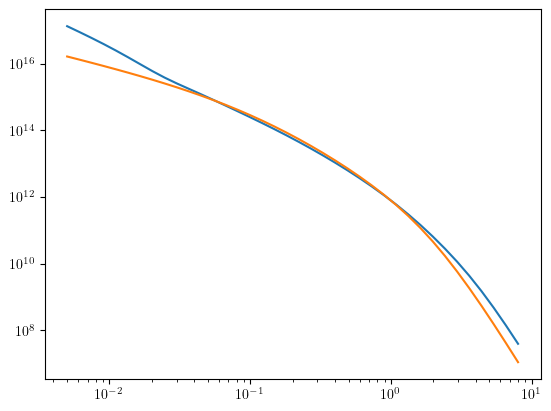

In [6]:
# Pmm_dmb_1h.shape
# Pmm_sup_mat = Pmm_dmb_tot/Pmm_nfw_tot
p1 = setup_power_test.rho_dmb_mat
p2 = setup_power_test.rho_nfw_mat
jM = 10
pl.figure()
# pl.plot(setup_power_test.r_array, p1[:, 0,jM], label='1h dmb')
# pl.plot(setup_power_test.r_array, p2[:, 0,jM], label='1h dmb')
pl.plot(setup_power_test.r_array, p1[:, 4,jM], label='1h dmb')
pl.plot(setup_power_test.r_array, p2[:, 4,jM], label='1h dmb')

# pl.plot(setup_power_test.k, ratio[:, 12,jM], label='1h dmb')
pl.xscale('log')
pl.yscale('log')
# pl.ylim(0.7, 1.3)



(0.7, 1.3)

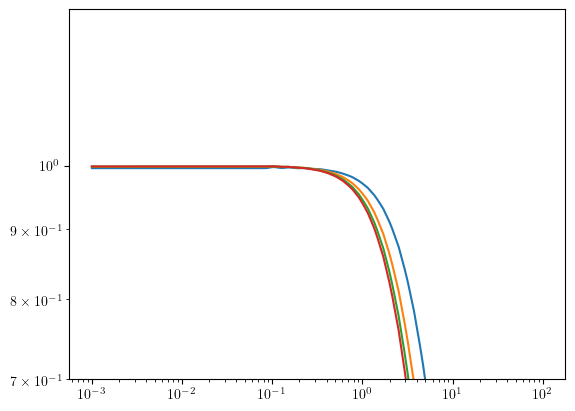

In [7]:
# ratio = setup_power_test.uk_dmb
ratio = setup_power_test.uk_nfw
# ratio.shape
jM = 5
pl.figure()
pl.plot(setup_power_test.k, ratio[:, 0,jM], label='1h dmb')
pl.plot(setup_power_test.k, ratio[:, 4,jM], label='1h dmb')
pl.plot(setup_power_test.k, ratio[:, 8,jM], label='1h dmb')
pl.plot(setup_power_test.k, ratio[:, 12,jM], label='1h dmb')
pl.xscale('log')
pl.yscale('log')
pl.ylim(0.7, 1.3)



(0.7, 1.3)

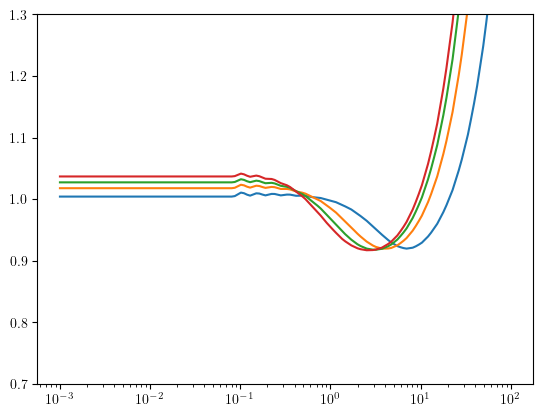

In [8]:
ratio = setup_power_test.uk_dmb/setup_power_test.uk_nfw
# ratio.shape
jM = 5
pl.figure()
pl.plot(setup_power_test.k, ratio[:, 0,jM], label='1h dmb')
pl.plot(setup_power_test.k, ratio[:, 4,jM], label='1h dmb')
pl.plot(setup_power_test.k, ratio[:, 8,jM], label='1h dmb')
pl.plot(setup_power_test.k, ratio[:, 12,jM], label='1h dmb')
pl.xscale('log')
pl.ylim(0.7, 1.3)


(0.7, 1.3)

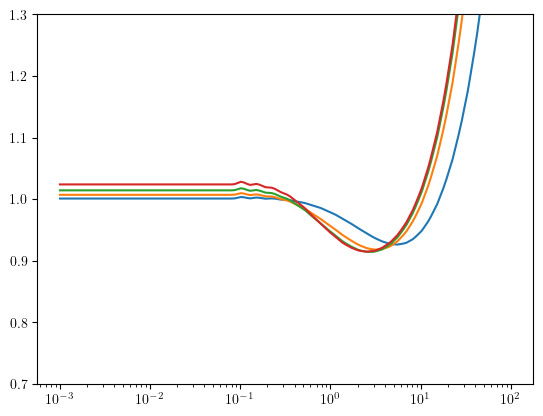

In [9]:
# 
ratio = setup_power_test.bm_dmb_2h/setup_power_test.bm_nfw_2h

pl.figure()
pl.plot(setup_power_test.k, ratio[:, 0], label='1h dmb')
pl.plot(setup_power_test.k, ratio[:, 4], label='1h dmb')
pl.plot(setup_power_test.k, ratio[:, 8], label='1h dmb')
pl.plot(setup_power_test.k, ratio[:, 12], label='1h dmb')
pl.xscale('log')
pl.ylim(0.7, 1.3)


(0.7, 1.1)

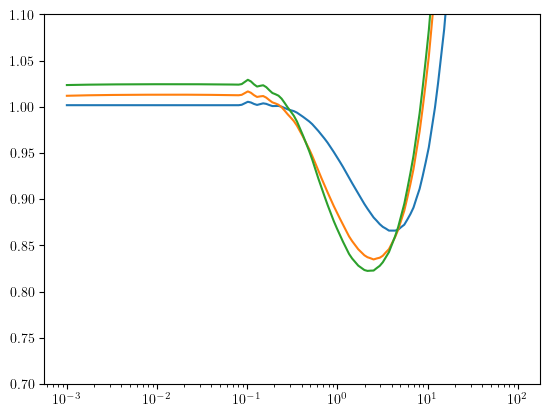

In [10]:
Pmm_sup_mat = Pmm_dmb_tot/Pmm_nfw_tot
pl.figure()
pl.plot(setup_power_test.k, Pmm_sup_mat[:, 0], label='1h dmb')
pl.plot(setup_power_test.k, Pmm_sup_mat[:, 4], label='1h dmb')
pl.plot(setup_power_test.k, Pmm_sup_mat[:, 8], label='1h dmb')
# pl.plot(setup_power_test.k, Pmm_sup_mat[:, 12], label='1h dmb')
pl.xscale('log')
pl.ylim(0.7, 1.1)



In [87]:
setup_power_test.z_array


Array([0.01, 0.14, 0.27, 0.4 , 0.53, 0.66, 0.79, 0.92, 1.05, 1.18, 1.31,
       1.44, 1.57, 1.7 , 1.83, 1.96, 2.09, 2.22, 2.35, 2.48, 2.61, 2.74,
       2.87, 3.  ], dtype=float64)

In [82]:
import copy
from tqdm import tqdm
# from get_corr_func_jit import get_corrfunc_BCMP
from get_corr_func import get_corrfunc_BCMP
# sim_params_dict['nu_theta_ej_M'] = -0.1
get_corrfunc_BCMP_test = get_corrfunc_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, verbose_time=False)


1.0
